In [13]:
from pathlib import Path
import sqlite3
import pandas as pd

# Change this to wherever your dataset folder is
BASE_DIR = Path(r"C:\Users\J1999\Downloads\revblack_synthetic_revops_dataset\revblack_synthetic_revops_dataset")

DB_PATH = BASE_DIR / "revops_salesforce_hubspot.db"
OUT_DIR = BASE_DIR / "dashboard_ready_outputs"
OUT_DIR.mkdir(exist_ok=True)

conn = sqlite3.connect(DB_PATH)

dashboard_tables = [
    "dashboard_lead_funnel_monthly",
    "dashboard_open_pipeline_health_by_stage",
    "dashboard_campaign_roi",
    "dashboard_sync_health_by_error",
    "dashboard_crm_data_quality_audit"
]

for table in dashboard_tables:
    df = pd.read_sql(f"SELECT * FROM {table}", conn)
    df.to_csv(OUT_DIR / f"{table}.csv", index=False)
    print(f"Saved {table}: {len(df)} rows")

conn.close()

Saved dashboard_lead_funnel_monthly: 180 rows
Saved dashboard_open_pipeline_health_by_stage: 5 rows
Saved dashboard_campaign_roi: 15 rows
Saved dashboard_sync_health_by_error: 49 rows
Saved dashboard_crm_data_quality_audit: 9 rows


In [14]:
# python visuals because why not
!pip install plotly kaleido
import plotly.express as px

In [15]:
from pathlib import Path
import pandas as pd

# Update if needed
BASE_DIR = Path(r"C:\Users\J1999\Downloads\revblack_synthetic_revops_dataset\revblack_synthetic_revops_dataset")
OUT_DIR = BASE_DIR / "dashboard_ready_outputs"
VIS_DIR = BASE_DIR / "plotly_visuals"
VIS_DIR.mkdir(exist_ok=True)

print("Reading CSVs from:", OUT_DIR)
print("Saving visuals to:", VIS_DIR)

Reading CSVs from: C:\Users\J1999\Downloads\revblack_synthetic_revops_dataset\revblack_synthetic_revops_dataset\dashboard_ready_outputs
Saving visuals to: C:\Users\J1999\Downloads\revblack_synthetic_revops_dataset\revblack_synthetic_revops_dataset\plotly_visuals


## Lead funnel over time

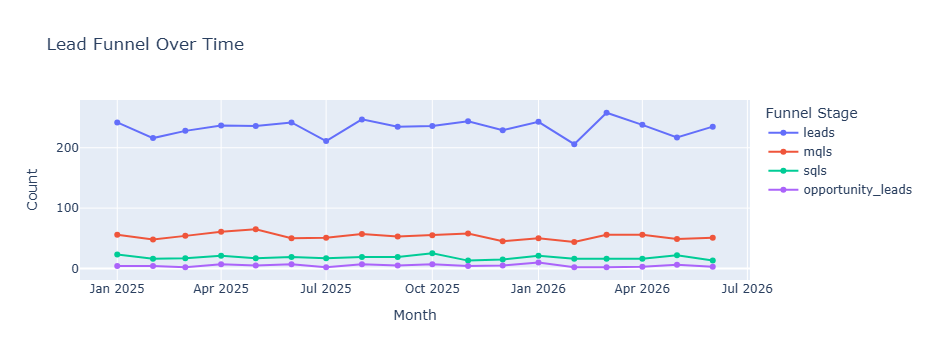

In [16]:
lead_funnel = pd.read_csv(OUT_DIR / "dashboard_lead_funnel_monthly.csv")
lead_funnel["lead_month"] = pd.to_datetime(lead_funnel["lead_month"])

lead_monthly = (
    lead_funnel
    .groupby("lead_month", as_index=False)
    .agg(
        leads=("leads", "sum"),
        mqls=("mqls", "sum"),
        sqls=("sqls", "sum"),
        opportunity_leads=("opportunity_leads", "sum"),
        avg_speed_to_lead_hours=("avg_speed_to_lead_hours", "mean")
    )
)

lead_long = lead_monthly.melt(
    id_vars="lead_month",
    value_vars=["leads", "mqls", "sqls", "opportunity_leads"],
    var_name="funnel_stage",
    value_name="count"
)

fig = px.line(
    lead_long,
    x="lead_month",
    y="count",
    color="funnel_stage",
    markers=True,
    title="Lead Funnel Over Time"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Count",
    legend_title="Funnel Stage"
)

fig.show()
fig.write_html(VIS_DIR / "01_lead_funnel_over_time.html")

## Open pipeline by stage

In [17]:
pipeline = pd.read_csv(OUT_DIR / "dashboard_open_pipeline_health_by_stage.csv")

pipeline_stage = pipeline.sort_values("open_pipeline", ascending=True)

fig = px.bar(
    pipeline_stage,
    x="open_pipeline",
    y="stage_name",
    orientation="h",
    text="opps",
    title="Open Pipeline by Stage",
    hover_data=["expected_revenue", "stale_opps", "stale_rate"]
)

fig.update_layout(
    xaxis_title="Open Pipeline $",
    yaxis_title="Stage"
)

fig.update_traces(texttemplate="%{text} opps", textposition="outside")

fig.show()
fig.write_html(VIS_DIR / "02_open_pipeline_by_stage.html")

## Top campaign ROI

In [18]:
campaign_roi = pd.read_csv(OUT_DIR / "dashboard_campaign_roi.csv")

top_campaigns = campaign_roi.sort_values("won_revenue_to_budget", ascending=True).tail(15)

fig = px.bar(
    top_campaigns,
    x="won_revenue_to_budget",
    y="campaign_name",
    orientation="h",
    text="won_revenue_to_budget",
    title="Top Campaigns by Won Revenue-to-Budget Ratio",
    hover_data=["campaign_type", "budget", "members", "engaged_members", "influenced_opportunities", "won_revenue", "expected_revenue"]
)

fig.update_layout(
    xaxis_title="Won Revenue / Budget",
    yaxis_title="Campaign"
)

fig.update_traces(texttemplate="%{text:.2f}x", textposition="outside")

fig.show()
fig.write_html(VIS_DIR / "03_top_campaign_roi.html")

## Sync errors by type and status

In [19]:
sync_health = pd.read_csv(OUT_DIR / "dashboard_sync_health_by_error.csv")

sync_by_error_status = (
    sync_health
    .groupby(["error_type", "status"], as_index=False)
    .agg(errors=("errors", "sum"))
)

fig = px.bar(
    sync_by_error_status,
    x="error_type",
    y="errors",
    color="status",
    title="Salesforce-HubSpot Sync Errors by Type and Status",
    hover_data=["status", "errors"]
)

fig.update_layout(
    xaxis_title="Error Type",
    yaxis_title="Errors",
    legend_title="Status",
    xaxis_tickangle=-35
)

fig.show()
fig.write_html(VIS_DIR / "04_sync_errors_by_type_status.html")

## CRM data quality missing-rate audit

In [20]:
dq = pd.read_csv(OUT_DIR / "dashboard_crm_data_quality_audit.csv")

dq["crm_field"] = dq["object_name"] + "." + dq["field_name"]
dq_sorted = dq.sort_values("missing_rate", ascending=True)

fig = px.bar(
    dq_sorted,
    x="missing_rate",
    y="crm_field",
    orientation="h",
    color="severity",
    title="CRM Data Quality Audit: Missing Rate by Field",
    hover_data=["business_impact", "recommended_fix"]
)

fig.update_layout(
    xaxis_title="Missing Rate",
    yaxis_title="CRM Field",
    legend_title="Severity"
)

fig.update_xaxes(tickformat=".0%")

fig.show()
fig.write_html(VIS_DIR / "05_crm_data_quality_missing_rate.html")